In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/2025-sep-dl-gen-ai-project/sample_submission.csv
/kaggle/input/2025-sep-dl-gen-ai-project/train.csv
/kaggle/input/2025-sep-dl-gen-ai-project/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import html
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,accuracy_score



import torch
from torch import nn
from torch.utils.data import Dataset,DataLoader

# EDA and Feature Engineering

In [3]:
train_data = pd.read_csv('/kaggle/input/2025-sep-dl-gen-ai-project/train.csv')
test_data = pd.read_csv('/kaggle/input/2025-sep-dl-gen-ai-project/test.csv')
sample = pd.read_csv('/kaggle/input/2025-sep-dl-gen-ai-project/sample_submission.csv')

In [4]:
train_data.head()

,id,text,anger,fear,joy,sadness,surprise,emotions
0,0,the dentist that did the work apparently did a...,1,0,0,1,0,['anger' 'sadness']
1,1,i'm gonna absolutely ~~suck~~ be terrible duri...,0,1,0,1,0,['fear' 'sadness']
2,2,"bridge: so leave me drowning calling houston, ...",0,1,0,1,0,['fear' 'sadness']
3,3,after that mess i went to see my now ex-girlfr...,1,1,0,1,0,['anger' 'fear' 'sadness']
4,4,"as he stumbled i ran off, afraid it might some...",0,1,0,0,0,['fear']


In [5]:
print(train_data.shape)

(6827, 8)


In [6]:
print(train_data.isna().sum())

id          0
text        0
anger       0
fear        0
joy         0
sadness     0
surprise    0
emotions    0
dtype: int64


In [7]:
print(f"train_data has {train_data.duplicated('text').sum()} duplicates text")

train_data has 1841 duplicates text


In [8]:
noisy_examples = train_data[train_data["text"].str.contains("[^a-zA-Z0-9.,!?/' ]")]["text"].head(10)
print("Noisy text samples:\n")
for t in noisy_examples:
    print("*", t)


Noisy text samples:

* i'm gonna absolutely ~~suck~~ be terrible during my first sexual experience ._.
* bridge: so leave me drowning calling houston, and let my lungs cave in, from calling god, for my mistakes and to the one who deserves the apology.
* after that mess i went to see my now ex-girlfriend at school because she refused to drive home to see me.
* " and burst into tears.
* first me, a slight stir from my legs, a stretching of my toes, and immediately following my father says, `` hmm? ''
* the song `` poor places '' is ironically seeping out of my speakers and into my ears: it's hot in the poor places tonight / i'm not going outside
* so i was like "wtf, you have the bag, read the bag.
* `` i felt my eyelids swelling shut and the crack in my collarbone started to throb.
* i never saw that thing again, because evidently it was "stolen".
* "  i'm like "sure.


In [9]:
train_data.head()

,id,text,anger,fear,joy,sadness,surprise,emotions
0,0,the dentist that did the work apparently did a...,1,0,0,1,0,['anger' 'sadness']
1,1,i'm gonna absolutely ~~suck~~ be terrible duri...,0,1,0,1,0,['fear' 'sadness']
2,2,"bridge: so leave me drowning calling houston, ...",0,1,0,1,0,['fear' 'sadness']
3,3,after that mess i went to see my now ex-girlfr...,1,1,0,1,0,['anger' 'fear' 'sadness']
4,4,"as he stumbled i ran off, afraid it might some...",0,1,0,0,0,['fear']


In [10]:
emotion_counts = train_data[['anger', 'fear', 'joy', 'sadness', 'surprise']].sum()
print(emotion_counts)

anger        808
fear        3860
joy         1660
sadness     2171
surprise    1999
dtype: int64


In [11]:
labels = [
    'anger',
    'fear',
    'joy',
    'sadness',
    'surprise'
]

total = len(train_data)

train_data['any_label'] = (train_data[labels].sum(axis=1) > 0).astype(int)

all_labels = labels + ['any_label']

print("Training Data Comment Breakdown \n")

for base_label in all_labels:

    base_total = train_data[base_label].sum()
    base_percent = base_total / total * 100

    print(f"{base_total} {base_label} comments. "
          f"({base_percent:.2f}% of all data.)")

    for other_label in all_labels:
        if other_label != base_label:

            both = train_data[(train_data[base_label] == 1) &
                      (train_data[other_label] == 1)].shape[0]

            percent = both / base_total * 100 if base_total > 0 else 0

            print(f"- {both} or {percent:.2f}% "
                  f"were also {other_label}.")

    print()

Training Data Comment Breakdown 

808 anger comments. (11.84% of all data.)
- 544 or 67.33% were also fear.
- 17 or 2.10% were also joy.
- 354 or 43.81% were also sadness.
- 256 or 31.68% were also surprise.
- 808 or 100.00% were also any_label.

3860 fear comments. (56.54% of all data.)
- 544 or 14.09% were also anger.
- 251 or 6.50% were also joy.
- 1685 or 43.65% were also sadness.
- 1378 or 35.70% were also surprise.
- 3860 or 100.00% were also any_label.

1660 joy comments. (24.32% of all data.)
- 17 or 1.02% were also anger.
- 251 or 15.12% were also fear.
- 96 or 5.78% were also sadness.
- 357 or 21.51% were also surprise.
- 1660 or 100.00% were also any_label.

2171 sadness comments. (31.80% of all data.)
- 354 or 16.31% were also anger.
- 1685 or 77.61% were also fear.
- 96 or 4.42% were also joy.
- 469 or 21.60% were also surprise.
- 2171 or 100.00% were also any_label.

1999 surprise comments. (29.28% of all data.)
- 256 or 12.81% were also anger.
- 1378 or 68.93% were also 

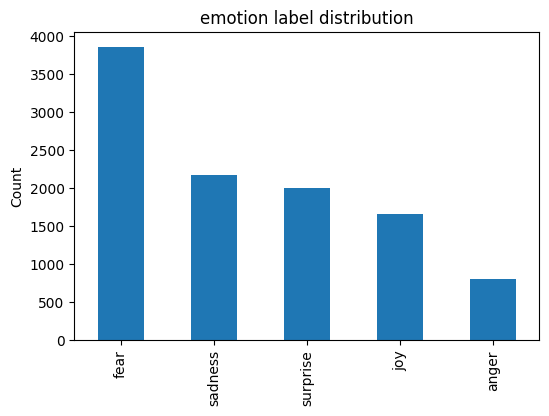

In [12]:
train_data[labels].sum().sort_values(ascending = False).plot(kind = 'bar',figsize = (6,4))
plt.title('emotion label distribution')
plt.ylabel('Count')
plt.show()

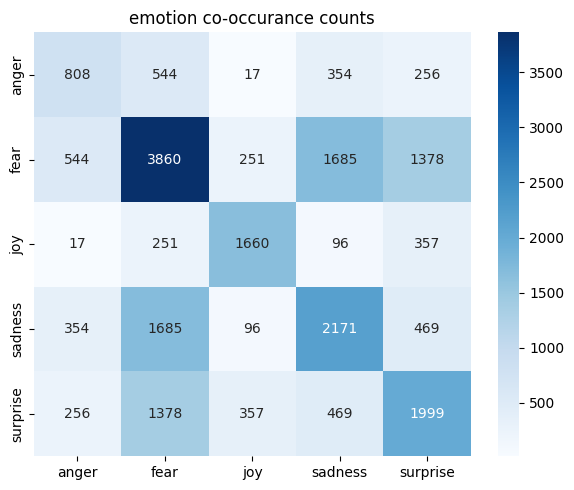

In [13]:
corr_count = train_data[labels].T@train_data[labels]
plt.figure(figsize = (6,5))

sns.heatmap(corr_count,annot = True,fmt = 'd',cmap = 'Blues')
plt.title('emotion co-occurance counts')
plt.tight_layout()

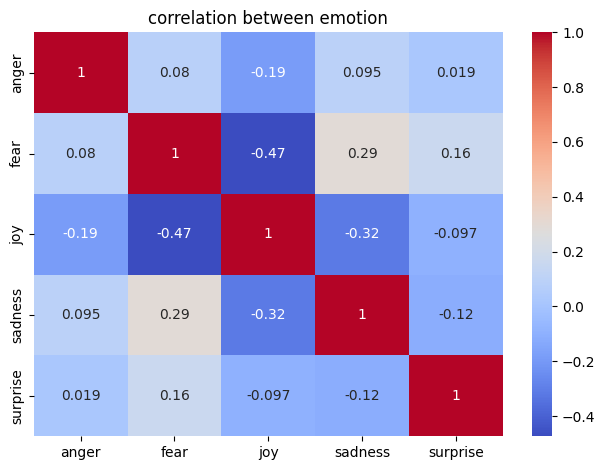

In [14]:
corr = train_data[labels].corr()
sns.heatmap(corr,annot = True,cmap = 'coolwarm')
plt.title('correlation between emotion')
plt.tight_layout()

In [15]:
text_col = 'clean_text' if 'clean_text' in train_data.columns else 'text'

if 'text_len' not in train_data.columns:
    train_data['text_len'] = train_data[text_col].astype(str).str.len()


has_any = train_data[labels].sum(axis = 1) > 0

dom_emotion = train_data.loc[has_any,labels].idxmax(axis = 1)

tmp = train_data.loc[has_any].copy()
tmp['dominant_emotion'] = dom_emotion
tmp.head()

,id,text,anger,fear,joy,sadness,surprise,emotions,any_label,text_len,dominant_emotion
0,0,the dentist that did the work apparently did a...,1,0,0,1,0,['anger' 'sadness'],1,153,anger
1,1,i'm gonna absolutely ~~suck~~ be terrible duri...,0,1,0,1,0,['fear' 'sadness'],1,79,fear
2,2,"bridge: so leave me drowning calling houston, ...",0,1,0,1,0,['fear' 'sadness'],1,146,fear
3,3,after that mess i went to see my now ex-girlfr...,1,1,0,1,0,['anger' 'fear' 'sadness'],1,105,anger
4,4,"as he stumbled i ran off, afraid it might some...",0,1,0,0,0,['fear'],1,73,fear


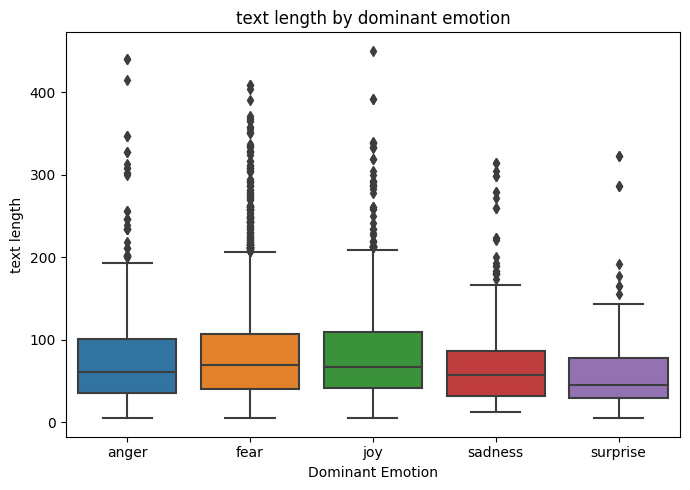

In [16]:
plt.figure(figsize = (7,5))
sns.boxplot(data = tmp,x = 'dominant_emotion',y = 'text_len')
plt.xlabel('Dominant Emotion')
plt.ylabel('text length')
plt.title('text length by dominant emotion')
plt.tight_layout()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


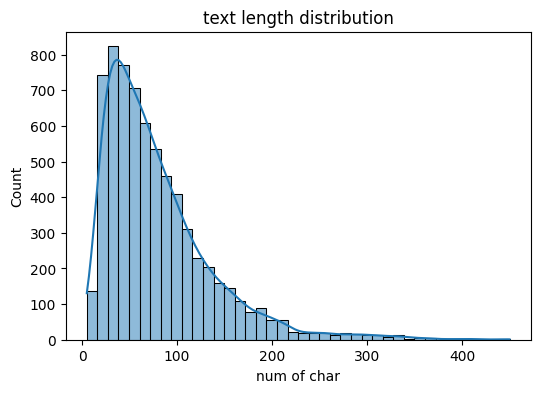

In [17]:
train_data['text_length'] = train_data['text'].astype(str).apply(len)

plt.figure(figsize = (6,4))
sns.histplot(train_data['text_length'],bins = 40,kde = True)
plt.title('text length distribution')
plt.xlabel('num of char')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


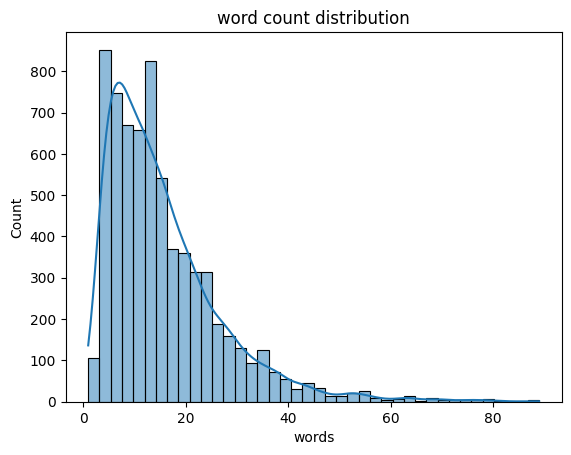

In [18]:
train_data['word_count'] = train_data['text'].apply(lambda x: len(str(x).split()))
sns.histplot(train_data['word_count'],bins = 40,kde = True)
plt.title('word count distribution')
plt.xlabel('words')
plt.show()

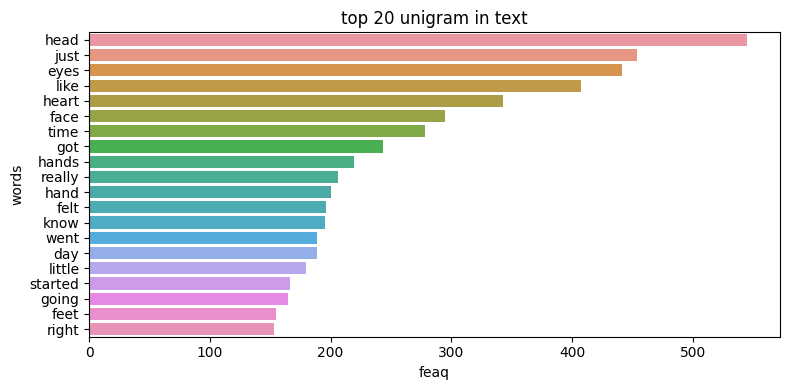

In [19]:

corpus = train_data[text_col].astype(str).tolist()

vector = CountVectorizer(max_features = 2000,stop_words = 'english')

x = vector.fit_transform(corpus)

word_counts = np.asarray(x.sum(axis=0)).ravel()
vocab  = np.array(vector.get_feature_names_out())

top_idx = word_counts.argsort()[::-1][:20]
top_words = vocab[top_idx]
top_val = word_counts[top_idx]

plt.figure(figsize = (8,4))

sns.barplot(x = top_val,y = top_words)
plt.xlabel('feaq')
plt.ylabel('words')
plt.title('top 20 unigram in text')

plt.tight_layout()


In [20]:

def clean_text(text):
    if not isinstance(text,str):
        return ''
    text = html.unescape(text)
    text = text.encode('ascii','ignore').decode()
    text = re.sub(r'\s+'," ",text).strip()
    return text


train_data['clean_text'] = train_data['text'].apply(clean_text)
test_data['clean_text'] = train_data['text'].apply(clean_text)



In [21]:
train_data['text'] = train_data['text'].astype(str).fillna("")
test_data['text'] = test_data['text'].astype(str).fillna("")

In [22]:
vectorizer = TfidfVectorizer(ngram_range = (1,2),stop_words = 'english')
x = vectorizer.fit_transform(train_data['text'])
x.shape

(6827, 33896)

In [23]:
emotion = train_data[labels].sum().sort_values(ascending=False)

print("\nMost common emotion:", emotion.idxmax())
print("Count:", emotion.max())


Most common emotion: fear
Count: 3860


In [24]:

# It removes all the puncuation 
train_data['clean_text'] = train_data['clean_text'].astype(str).str.lower()

def remove(text):
    return text.translate(str.maketrans('','',string.punctuation))

train_data['clean_text'] = train_data['clean_text'].apply(remove)


In [25]:
labels = ["anger", "fear", "joy", "sadness", "surprise"]
text_col = "text_clean" if "text_clean" in train_data.columns else "text"
print("Using text column:", text_col)


Using text column: text


In [26]:
for col in labels:
    train_data[col] = train_data[col].astype('float32')

train_df,val_df = train_test_split(train_data,
                                   test_size = 0.1,
                                  random_state = 42,
                                   stratify=train_data[labels].values.argmax(axis=1))

In [27]:
train_texts = train_df[text_col].astype(str).tolist()
val_texts = val_df[text_col].astype(str).tolist()
test_texts = test_data[text_col if text_col in test_data.columns else "text"].astype(str).tolist()

y_train = train_df[labels].values.astype('float32')
y_val = train_df[labels].values.astype('float32')

In [28]:
print(train_df.shape,val_df.shape)
print(y_train.shape,y_val.shape)

(6144, 13) (683, 13)
(6144, 5) (6144, 5)


In [29]:

MAX_VOCAB_SIZE = 20000
MAX_LEN = 80  

counter = Counter()
for text in train_texts:
    counter.update(text.split())

most_common = counter.most_common(MAX_VOCAB_SIZE - 2)

stoi = {"<PAD>": 0, "<UNK>": 1}
for idx, (word, _) in enumerate(most_common, start=2):
    stoi[word] = idx

vocab_size = len(stoi)
print("Vocab size:", vocab_size)

def encode_text(text, stoi_dict, max_len):
    tokens = text.split()
    ids = [stoi_dict.get(tok, 1) for tok in tokens][:max_len]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids

X_train_ids = np.array([encode_text(t, stoi, MAX_LEN) for t in train_texts], dtype="int64")
X_val_ids = np.array([encode_text(t, stoi, MAX_LEN) for t in val_texts], dtype="int64")
X_test_ids = np.array([encode_text(t, stoi, MAX_LEN) for t in test_texts], dtype="int64")

print("Train IDs:", X_train_ids.shape, "Val IDs:", X_val_ids.shape, "Test IDs:", X_test_ids.shape)

     

Vocab size: 11183
Train IDs: (6144, 80) Val IDs: (683, 80) Test IDs: (1707, 80)


# Model 1 (BILSTM)

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [31]:
class Lstmdataset(Dataset):
    def __init__(self,x,y = None):
        self.x = torch.tensor(x,dtype = torch.long)
        self.y = None
        if y is not None:
            self.y = torch.tensor(y,dtype = torch.float)
    def __len__(self):
        return (len(self.x))
    def __getitem__(self,idx):
        if self.y is None:
            return self.x[idx]
        return self.x[idx],self.y[idx]

batch_size = 64

train_data_lstm = Lstmdataset(X_train_ids,y_train)
val_data_lstm = Lstmdataset(X_val_ids,y_train)
test_data_lstm = Lstmdataset(X_test_ids,None)

In [32]:
train_loader = DataLoader(train_data_lstm,batch_size =64,shuffle = True)
val_loader = DataLoader(val_data_lstm,batch_size =64,shuffle = True)
test_loader = DataLoader(test_data_lstm,batch_size =64,shuffle = True)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

96
11
27


In [33]:
class BiLSTM(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_dim,num_labels):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size,embed_dim,padding_idx = 0)
        self.lstm = nn.LSTM(embed_dim,hidden_dim,batch_first = True,bidirectional = True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim*2,num_labels)

    def forward(self,x):
        x = self.embedding(x)
        output,(h_n,c_n) = self.lstm(x)
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h_cat = torch.cat((h_forward,h_backward),dim = 1)
        x = self.dropout(h_cat)
        logit = self.fc(x)
        return logit


embed_dim = 128
hidden_dim = 128
num_labels = len(labels)

bilstm_model = BiLSTM(vocab_size,embed_dim,hidden_dim,num_labels).to(device)


        
bilstm_model      
        
        

BiLSTM(
  (embedding): Embedding(11183, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=5, bias=True)
)

In [34]:
criterion = nn.BCEWithLogitsLoss()
optimizer =  torch.optim.Adam(bilstm_model.parameters(),lr = 1e-3)


In [35]:
def evaluate_lstm(model,dataloader,device,threshold = 0.5):
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs,lables in dataloader:
            inputs = inputs.to(device)
            labels = lables.to(device)

            logits = model(inputs)
            probs = torch.sigmoid(logits)
            pred = (probs > threshold).float()
            all_labels.append(lables.cpu().numpy())
            all_preds.append(pred.cpu().numpy())
    all_labels = np.concatenate(all_labels,axis = 0)
    all_preds = np.concatenate(all_preds,axis = 0)

    macro_f1 =  f1_score(all_labels,all_preds,average='macro',zero_division = 0)
    acc  = accuracy_score(all_labels,all_preds)
    return macro_f1,acc

In [36]:
best_val_f1 = 0.0
best_state_dict = None
epochs = 10

for epoch in range(epochs):
    bilstm_model.train()
    loss = 0.0
    for inputs,label in train_loader:
        inputs = inputs.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        logits = bilstm_model(inputs)
        loss = criterion(logits,label)
        loss.backward()
        optimizer.step()
        loss += loss.item()*inputs.size(0)
    train_loss = loss/len(train_loader.dataset)
    val_f1,val_acc = evaluate_lstm(bilstm_model,val_loader,device)


    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state_dict = bilstm_model.state_dict()
    print(
        f"Epoch {epoch + 1}/{epochs} - loss: {train_loss:.4f} - val_f1: {val_f1:.4f} - val_acc: {val_acc:.4f}"
    )


if best_state_dict is not None:
    bilstm_model.load_state_dict(best_state_dict)

print('best validation macro f:',best_val_f1)


Epoch 1/10 - loss: 0.0059 - val_f1: 0.1499 - val_acc: 0.1318
Epoch 2/10 - loss: 0.0057 - val_f1: 0.1939 - val_acc: 0.1098
Epoch 3/10 - loss: 0.0055 - val_f1: 0.2378 - val_acc: 0.1113
Epoch 4/10 - loss: 0.0044 - val_f1: 0.2779 - val_acc: 0.1259
Epoch 5/10 - loss: 0.0041 - val_f1: 0.2670 - val_acc: 0.1127
Epoch 6/10 - loss: 0.0034 - val_f1: 0.2754 - val_acc: 0.1142
Epoch 7/10 - loss: 0.0027 - val_f1: 0.2809 - val_acc: 0.1157
Epoch 8/10 - loss: 0.0021 - val_f1: 0.3015 - val_acc: 0.1127
Epoch 9/10 - loss: 0.0018 - val_f1: 0.2905 - val_acc: 0.1201
Epoch 10/10 - loss: 0.0013 - val_f1: 0.2947 - val_acc: 0.1142
best validation macro f: 0.30145958628599867


In [37]:
bilstm_model.eval()
all_test_preds = []

with torch.no_grad():
    for inputs in test_loader:
        inputs = inputs.to(device)
        logits = bilstm_model(inputs)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float().cpu().numpy()
        all_test_preds.append(preds)


all_test_preds = np.vstack(all_test_preds)

submission_bilstm_model = pd.DataFrame(all_test_preds,columns = labels)
submission_bilstm_model.insert(0,'id',test_data['id'])

submission_bilstm_model.to_csv('bilstm_model.csv',index = False)

print(submission_bilstm_model)

        id  anger  fear  joy  sadness  surprise
0        0    0.0   1.0  0.0      1.0       0.0
1        1    0.0   1.0  0.0      1.0       0.0
2        2    0.0   0.0  0.0      0.0       1.0
3        3    0.0   1.0  0.0      0.0       1.0
4        4    0.0   1.0  0.0      1.0       0.0
...    ...    ...   ...  ...      ...       ...
1702  1702    0.0   1.0  0.0      0.0       0.0
1703  1703    0.0   1.0  0.0      1.0       0.0
1704  1704    0.0   0.0  0.0      0.0       1.0
1705  1705    0.0   1.0  0.0      0.0       0.0
1706  1706    0.0   0.0  0.0      0.0       0.0

[1707 rows x 6 columns]


# BILSTM WITH ATTENTION

In [38]:
device = torch.device('cpu' if torch.cuda.is_available() else 'cpu')


text_col = 'text_clean' if 'text_clean' in train_data.columns else 'text'

labels = ['anger','fear','joy','sadness','surprise']

max_len2 = 80
embed_dim = 128
hidden_dim = 128
batch_size = 64
epochs = 12
lr2 = 1e-3

In [39]:
labels

['anger', 'fear', 'joy', 'sadness', 'surprise']

In [40]:
counter2 = Counter()

for t in train_data[text_col].astype(str):
    counter2.update(t.split())


stoi2 = {"<PAD>": 0, "<UNK>": 1}

for w in counter2.keys():
    if w not in stoi2:
        stoi2[w] = len(stoi2)

vocab_size = len(stoi2)

In [41]:
def encode_text2(text):
    tokens = str(text).split()
    ids = [stoi2.get(tok,1) for tok in tokens[:max_len2]]
    if len(ids) < max_len2:
        ids += [0]*(max_len2-len(ids))
    return ids

In [42]:
class Textdataset2(Dataset):
    def __init__(self,texts,labels = None):
        x = [encode_text2(t) for t in texts]
        self.x = torch.tensor(np.array(x,dtype = 'int64'),dtype = torch.long)
        self.y = None if labels is None else torch.tensor(labels.astype('float32'),dtype = torch.float32)

    def __len__(self):
        return len(self.x)
    def __getitem__(self,idx):
        if self.y is None:
            return self.x[idx]
        return self.x[idx],self.y[idx]

x_all2 = train_data[text_col].astype(str).values
y_all2 = train_data[labels].values

x_train,x_val,y_train,y_val = train_test_split(x_all2,y_all2,test_size = 0.15,random_state = 42)

train_ds2 = Textdataset2(x_train,y_train)
val_ds2 = Textdataset2(x_val,y_val)

train_loader2 = DataLoader(train_ds2, batch_size=batch_size, shuffle=True)
val_loader2 = DataLoader(val_ds2, batch_size=batch_size, shuffle=False)


In [43]:
class BiLstmAttn(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_dim,num_labels):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size,embed_dim,padding_idx = 0)
        self.lstm = nn.LSTM(embed_dim,hidden_dim,batch_first =True,bidirectional = True)
        self.attn = nn.Linear(hidden_dim*2,hidden_dim)
        self.v = nn.Linear(hidden_dim,1,bias = False)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim*2,num_labels)
    def forward(self,x):
        x = self.embedding(x)
        outputs,(h,c) = self.lstm(x)
        u = torch.tanh(self.attn(outputs))
        scores = self.v(u).squeeze(-1)
        alpha = torch.softmax(scores,dim = 1).unsqueeze(-1)
        context = torch.sum(alpha * outputs, dim=1)
        context = self.dropout(context)
        logits = self.fc(context)
        return logits





In [44]:
def train_model(model,loader,optimizer,criterion):
    model.train()
    total_loss = 0.0
    for x,y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits,y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()*x.size(0)
    return total_loss/len(loader.dataset)

In [45]:
def eval_model(model,loader,criterion):
    model.eval()
    total_loss  = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = criterion(logits,y)
            total_loss += loss.item()*x.size(0)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            all_preds.append(preds)
            all_targets.append(y.cpu().numpy())
    y_true = np.vstack(all_targets)
    y_preds = np.vstack(all_preds)
    macro_f1 = f1_score(y_true,y_preds,average = 'macro')
    acc = accuracy_score(y_true,y_preds)
    return total_loss/len(loader.dataset),macro_f1,acc
    

    

In [46]:
Bilstmwithattn_model = BiLstmAttn(vocab_size,embed_dim,hidden_dim,len(labels)).to(device)

optimizer2 = torch.optim.Adam(Bilstmwithattn_model.parameters(),lr =lr2)

criterion2 = nn.BCEWithLogitsLoss()

best_f1_2 = 0.0
best_state_2 = None
epochs2 = 10
for epochs in range(1,epochs2+1):
    train_loss_2 = train_model(Bilstmwithattn_model,train_loader2,optimizer2,criterion2)
    val_loss_2, val_f1_2, val_acc_2 = eval_model(Bilstmwithattn_model, val_loader2, criterion2)
    if val_f_2 := val_f1_2 > best_f1_2:
        best_f1_2 = val_f1_2
        best_state_2 = Bilstmwithattn_model.state_dict()



if best_state_2 is not None:
    Bilstmwithattn_model.load_state_dict(best_state_2)

In [47]:
test_texts2 = test_data[text_col].astype(str).values
X_test2 = np.array([encode_text2(t) for t in test_texts2], dtype="int64")
test_ds2 = Textdataset2(test_texts2)
test_ds2.X = torch.tensor(X_test2, dtype=torch.long)
test_loader2 = DataLoader(test_ds2, batch_size=batch_size, shuffle=False)

Bilstmwithattn_model.eval()
all_preds2 = []
with torch.no_grad():
    for X_batch in test_loader2:
        X_batch = X_batch.to(device)
        logits = Bilstmwithattn_model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_preds2.append(preds)

all_preds2 = np.vstack(all_preds2)

submission2 = pd.DataFrame(all_preds2, columns=labels)
submission2.insert(0, "id", test_data["id"])
submission2.to_csv('Bilstmwithattn_model.csv', index=False)
submission2.head()

,id,anger,fear,joy,sadness,surprise
0,0,1,0,0,0,0
1,1,0,0,0,0,0
2,2,1,1,0,0,1
3,3,0,1,0,0,0
4,4,0,1,0,0,1


# Classification with CNN

In [48]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TEXT_COL = "text_clean" if "text_clean" in train_data.columns else "text"
label_cols3 = ['anger','fear','joy','sadness','surprise']
MAX_LEN3 = 80
EMBED_DIM3 = 128
BATCH_SIZE3 = 64
EPOCHS3 = 12
LR3 = 1e-3
NUM_FILTERS3 = 128
FILTER_SIZES3 = [3, 4, 5]


In [49]:
counter3 = Counter()
for t in train_data[TEXT_COL].astype(str):
    counter3.update(t.split())

stoi3 = {"": 0, "": 1}
for w in counter3.keys():
    if w not in stoi3:
        stoi3[w] = len(stoi3)

vocab_size3 = len(stoi3)

def encode_text3(text):
    tokens = str(text).split()
    ids = [stoi3.get(tok, 1) for tok in tokens][:MAX_LEN3]
    if len(ids) < MAX_LEN3:
        ids += [0] * (MAX_LEN3 - len(ids))
    return ids

In [50]:
class TextDataset3(Dataset):
    def __init__(self, texts, labels=None):
        x = [encode_text3(t) for t in texts]
        self.X = torch.tensor(np.array(x, dtype="int64"), dtype=torch.long)
        self.y = None if labels is None else torch.tensor(labels.astype("float32"), dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

X_all3 = train_data[TEXT_COL].astype(str).values
y_all3 = train_data[label_cols3].values

X_train3, X_val3, y_train3, y_val3 = train_test_split(
    X_all3, y_all3, test_size=0.15, random_state=42
)

train_ds3 = TextDataset3(X_train3, y_train3)
val_ds3 = TextDataset3(X_val3, y_val3)

train_loader3 = DataLoader(train_ds3, batch_size=BATCH_SIZE3, shuffle=True)
val_loader3 = DataLoader(val_ds3, batch_size=BATCH_SIZE3, shuffle=False)

In [51]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, num_labels):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList(
            [nn.Conv1d(embed_dim, num_filters, kernel_size=k) for k in filter_sizes]
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_labels)
    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        xs = []
        for conv in self.convs:
            h = torch.relu(conv(x))
            h = torch.max(h, dim=2).values
            xs.append(h)
        x = torch.cat(xs, dim=1)
        x = self.dropout(x)
        logits = self.fc(x)
        return logits

In [52]:
def train_epoch3(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

In [53]:
def eval_epoch3(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            all_preds.append(preds)
            all_targets.append(y_batch.cpu().numpy())
    y_true = np.vstack(all_targets)
    y_pred = np.vstack(all_preds)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)
    return total_loss / len(loader.dataset), macro_f1, acc

     

In [54]:
model3 = TextCNN(vocab_size3, EMBED_DIM3, NUM_FILTERS3, FILTER_SIZES3, len(label_cols3)).to(DEVICE)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=LR3)
criterion3 = nn.BCEWithLogitsLoss()

best_f1_3 = 0.0
best_state_3 = None

for epoch in range(1, EPOCHS3 + 1):
    train_loss_3 = train_epoch3(model3, train_loader3, optimizer3, criterion3)
    val_loss_3, val_f1_3, val_acc_3 = eval_epoch3(model3, val_loader3, criterion3)
    if val_f1_3 > best_f1_3:
        best_f1_3 = val_f1_3
        best_state_3 = model3.state_dict()

    print(epoch, train_loss_3, val_loss_3, val_f1_3, val_acc_3)


if best_state_3 is not None:
    model3.load_state_dict(best_state_3)


1 0.5797553868467994 0.530994809895027 0.21836655962530083 0.144390243902439
2 0.5084523313602716 0.5000293328703903 0.3047770080300224 0.22048780487804878
3 0.4591673167973952 0.4671426871346264 0.379459736407958 0.2604878048780488
4 0.40083263564298827 0.44028753030590895 0.4243813766323906 0.2965853658536585
5 0.35649617751357227 0.4187847367728629 0.49996526134155744 0.3590243902439024
6 0.31176286912178097 0.3971194603094241 0.5944444564850077 0.44
7 0.2721633828536924 0.390738687195429 0.5831160756333406 0.46634146341463417
8 0.2400568551912015 0.3758936481650283 0.6375293675713302 0.5151219512195122
9 0.20904017592433896 0.37635432465774254 0.6692465216915888 0.5278048780487805
10 0.17794046376089276 0.381234687319616 0.6787528249029602 0.5424390243902439
11 0.1620057588176701 0.378929471635237 0.7036760044882733 0.5707317073170731
12 0.13698566722195957 0.3856882151888638 0.7128730887195732 0.5824390243902439


In [55]:
test_texts3 = test_data[TEXT_COL].astype(str).values
X_test3 = np.array([encode_text3(t) for t in test_texts3], dtype="int64")
test_ds3 = TextDataset3(test_texts3)
test_ds3.X = torch.tensor(X_test3, dtype=torch.long)
test_loader3 = DataLoader(test_ds3, batch_size=BATCH_SIZE3, shuffle=False)

model3.eval()
all_preds3 = []
with torch.no_grad():
    for X_batch in test_loader3:
        X_batch = X_batch.to(DEVICE)
        logits = model3(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_preds3.append(preds)

all_preds3 = np.vstack(all_preds3)

submission3 = pd.DataFrame(all_preds3, columns=label_cols3)
submission3.insert(0, "id", test_data["id"])

submission3.to_csv('textCNN.csv', index=False)
submission3.head()

,id,anger,fear,joy,sadness,surprise
0,0,0,0,0,0,0
1,1,0,0,0,0,0
2,2,1,1,0,0,0
3,3,0,1,0,0,0
4,4,0,1,0,0,1


# Classification using Pretrained Models

## DistilBERT

In [30]:
from transformers import AutoTokenizer,AutoModel,get_linear_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

text_col = 'text_clean' if 'text_clean' in train_data.columns else 'text'

labels = ['anger','fear','joy','sadness','surprise']


model_name = 'distilbert-base-uncased'
max_len = 64
batch_size = 12
epochs = 3
lr = 2e-5

In [31]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_batch(texts):
    return tokenizer(list(texts),
                    padding = 'max_length',
                    truncation = True,
                    max_length = max_len)



X_all4 = train_data[text_col].astype(str).values
y_all4 = train_data[labels].values.astype("float32")

X_train4, X_val4, y_train4, y_val4 = train_test_split(
    X_all4, y_all4, test_size=0.15, random_state=42
)

enc_train4 = tokenize_batch(X_train4)
enc_val4 = tokenize_batch(X_val4)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [40]:
class BertDataset(Dataset):
    def __init__(self,encoding,labels):
        self.encodings = encoding
        self.labels = labels

    def __len__(self):
        return len(self.encodings['input_ids'])
    def __getitem__(self,idx):
        item = {k:torch.tensor(v[idx],dtype = torch.long) for k,v in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx],dtype = torch.float32)
        return item


        
train_ds4 = BertDataset(enc_train4, y_train4)
val_ds4 = BertDataset(enc_val4, y_val4)

train_loader4 = DataLoader(train_ds4, batch_size=batch_size, shuffle=True)
val_loader4 = DataLoader(val_ds4, batch_size=batch_size, shuffle=False)
   


class BertMultilabel(nn.Module):
    def __init__(self,model_name,labels):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_size,labels)
    def forward(self,input_ids,attention_mask):
        outputs = self.bert(input_ids = input_ids,attention_mask = attention_mask)
        cls = outputs.last_hidden_state[:,0,:]
        x = self.dropout(cls)
        logits = self.classifier(x)
        return logits



def train_model(model,loader,optimizer,scheduler,criterion):
    model.train()
    total_loss = 0.0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        optimizer.zero_grad()
        logits = model(input_ids = input_ids,attention_mask = attention_mask)
        loss = criterion(logits,labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss +=loss.item()*input_ids.size(0)
    return total_loss/len(loader.dataset)


def eval_model(model,loader,criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            logits = model(input_ids = input_ids,attention_mask = attention_mask)
            loss = criterion(logits,labels)
            total_loss += loss.item()*input_ids.size(0)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            all_preds.append(preds)
            all_targets.append(labels.cpu().numpy())
    y_true = np.vstack(all_targets)
    y_preds = np.vstack(all_preds)
    macro_f1 = f1_score(y_true,y_preds,average = 'macro')
    acc = accuracy_score(y_true,y_preds)
    return total_loss/len(loader.dataset),macro_f1,acc
            

In [ ]:
BertMultilabel = BertMultilabel(model_name,len(labels)).to(device)
optimizer = torch.optim.AdamW(BertMultilabel.parameters(),lr = lr)

criterion = nn.BCEWithLogitsLoss()

total_steps4 = len(train_loader4) * epochs
scheduler4 = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps4),
    num_training_steps=total_steps4,
)

best_f1_4 = 0.0
best_state_4 = None


for epoch in range(1, epochs + 1):
    train_loss_4 = train_model(BertMultilabel, train_loader4, optimizer, scheduler4, criterion)
    val_loss_4, val_f1_4, val_acc_4 = eval_model(BertMultilabel, val_loader4, criterion)
    if val_f1_4 > best_f1_4:
        best_f1_4 = val_f1_4
        best_state_4 = BertMultilabel.state_dict()

    print(epoch, train_loss_4, val_loss_4, val_f1_4, val_acc_4)

if best_state_4 is not None:
    BertMultilabel.load_state_dict(best_state_4)


1 0.20110505298473472 0.27587290432395006 0.7871340927166677 0.5765853658536585


In [ ]:
X_test4 = test_data[text_col].astype(str).values
enc_test4 = tokenizer4(
    list(X_test4),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN4,
)

class BertTestDataset4(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __len__(self):
        return len(self.encodings["input_ids"])
    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx], dtype=torch.long) for k, v in self.encodings.items()}

test_ds4 = BertTestDataset4(enc_test4)
test_loader4 = DataLoader(test_ds4, batch_size=BATCH_SIZE4, shuffle=False)

BertMultilabel.eval()
all_preds4 = []
with torch.no_grad():
    for batch in test_loader4:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = model4(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_preds4.append(preds)

all_preds4 = np.vstack(all_preds4)

submission4 = pd.DataFrame(all_preds4, columns=labels)
submission4.insert(0, "id", test_data["id"])
submission4_path = ARTIFACT_DIR / "submission_model4_distilbert.csv"
submission4.to_csv('BertMultilabel.csv', index=False)
submission4.head()


> Key takeaways:
>  BiLSTM already provides a strong baseline
Attention and TextCNN offer small but consistent gains on some metrics
Pretrained transformers give the highest scores, at the cost of longer training time
Future improvements could include better class imbalance handling, smarter threshold tuning for multi-label outputs, and ensembling the top models for the final Kaggle submission.

